# Classical vs. Quantum Bug Classification — v4 (Three-Backbone Comparison)

**Task:** Binary classification of software-engineering bug reports as `classical` or `quantum`.

**This notebook compares three encoder backbones** holding architecture (RoBERTa-base, 125M params), hyperparameters, and CV protocol fixed:

| # | Model ID | Pretraining domain | What this isolates |
|---|---|---|---|
| 1 | `roberta-base` | English text only | Effect of *no* code-aware pretraining (control) |
| 2 | `microsoft/codebert-base` | Code + natural language (bimodal) | Effect of code-aware pretraining |
| 3 | `microsoft/graphcodebert-base` | Code + NL + data-flow graphs | Effect of structure-aware pretraining |

All three are 125M-parameter RoBERTa-architecture encoders, so any performance difference comes from **pretraining data**, not capacity or architecture.

**CV protocol:** 5-fold stratified × 5 seeds = 25 fold-runs per model = **75 fold-runs total**.

**Expected runtime on Kaggle T4:** ~75–110 min total (~25–35 min per model).


## 1. Install dependencies


In [6]:
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.44.2', 'datasets==2.21.0',
    'scikit-learn==1.5.2', 'accelerate==0.34.2',
], check=True)
print('Done.')

Done.


## 2. Imports & device check


In [7]:
%matplotlib inline
import json, os, random, gc, shutil, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold

# Note: EarlyStoppingCallback intentionally removed — replaced by ManualEarlyStoppingCallback
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    TrainerCallback, set_seed,
)
from datasets import Dataset
import transformers
transformers.logging.set_verbosity_error()

# Clean academic plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 13,
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 13,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})
PALETTE = {'classical': '#e74c3c', 'quantum': '#2980b9', 'mean': '#2c3e50'}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 3. Config


In [8]:
# ── Update this path to match your Kaggle dataset ─────────────────────────
DATA_PATH = '/kaggle/input/datasets/saidurlsu/classical-vs-quantum/bug_patterns_categorized.json'
# ──────────────────────────────────────────────────────────────────────────

# ── Model registry: three RoBERTa-architecture encoders, 125M params each ─
MODEL_REGISTRY = [
    {
        'name'        : 'roberta-base',
        'short'       : 'roberta',
        'description' : 'General-purpose text encoder (English only) — no code pretraining',
    },
    {
        'name'        : 'microsoft/codebert-base',
        'short'       : 'codebert',
        'description' : 'Code + NL bimodal pretraining (CodeSearchNet)',
    },
    {
        'name'        : 'microsoft/graphcodebert-base',
        'short'       : 'graphcodebert',
        'description' : 'Code + NL + data-flow graph pretraining',
    },
]

MAX_LEN      = 256
N_FOLDS      = 5
CV_SEEDS     = [42, 7, 2024, 99, 123]   # 5 seeds → 25 fold-runs per model

NUM_EPOCHS   = 12
LR           = 2e-5
BATCH_SIZE   = 8
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.15
DROPOUT      = 0.2
VAL_SPLIT    = 0.10
ES_PATIENCE  = 4

label_list = ['classical', 'quantum']
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for l, i in label2id.items()}
NUM_LABELS = 2

print('Models to compare:')
for m in MODEL_REGISTRY:
    print(f'  • {m["short"]:<14s}  ({m["name"]})')
print(f'CV protocol: {N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {N_FOLDS*len(CV_SEEDS)} folds per model')
print(f'Total fold-runs: {N_FOLDS*len(CV_SEEDS)*len(MODEL_REGISTRY)}')


Models to compare:
  • roberta         (roberta-base)
  • codebert        (microsoft/codebert-base)
  • graphcodebert   (microsoft/graphcodebert-base)
CV protocol: 5-fold × 5 seeds = 25 folds per model
Total fold-runs: 75


## 4. Load & inspect data


In [9]:
with open(DATA_PATH) as f:
    raw_data = json.load(f)

labeled = [x for x in raw_data if x.get('bug_category') in ('quantum', 'classical')]

n_classical = sum(1 for x in labeled if x['bug_category'] == 'classical')
n_quantum   = sum(1 for x in labeled if x['bug_category'] == 'quantum')

print(f'Total loaded   : {len(raw_data)}')
print(f'Labeled        : {len(labeled)}')
print(f'  classical    : {n_classical}  ({100*n_classical/len(labeled):.1f}%)')
print(f'  quantum      : {n_quantum}    ({100*n_quantum/len(labeled):.1f}%)')
print(f'Imbalance ratio: {n_classical/n_quantum:.2f}:1')

Total loaded   : 233
Labeled        : 233
  classical    : 134  (57.5%)
  quantum      : 99    (42.5%)
Imbalance ratio: 1.35:1


## 5. Text builder & arrays


In [10]:
def to_text(item):
    name = (item.get('name') or '').strip()
    desc = (item.get('description') or '').strip()
    code = (item.get('example_code') or '').strip()
    return '\n'.join(p for p in [name, desc, code] if p)

real_texts  = np.array([to_text(x) for x in labeled])
real_labels = np.array([label2id[x['bug_category']] for x in labeled])

print(f'Samples         : {len(real_texts)}')
print(f'Avg text length : {np.mean([len(t) for t in real_texts]):.0f} chars')

Samples         : 233
Avg text length : 225 chars


## 6. Callbacks + helpers


In [11]:
class ManualEarlyStoppingCallback(TrainerCallback):
    """
    Early stopping on macro-F1 that works with save_strategy='no'.
    Replaces HuggingFace EarlyStoppingCallback which requires
    load_best_model_at_end=True (and therefore checkpoint saving).
    """
    def __init__(self, patience=4):
        self.patience = patience
        self.best_f1  = -1.0
        self.wait     = 0

    def on_train_begin(self, args, state, control, **kwargs):
        # Reset state at the start of each fold
        self.best_f1 = -1.0
        self.wait    = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        current_f1 = metrics.get('eval_f1_macro', 0.0) if metrics else 0.0
        if current_f1 > self.best_f1 + 1e-4:
            self.best_f1 = current_f1
            self.wait    = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                control.should_training_stop = True


class EpochLogCallback(TrainerCallback):
    """Stores per-epoch val metrics for learning curve plotting."""
    def __init__(self, log_store):
        self.log_store = log_store

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.log_store.append({
                'epoch'    : state.epoch,
                'eval_loss': metrics.get('eval_loss',     float('nan')),
                'eval_acc' : metrics.get('eval_accuracy', float('nan')),
                'eval_f1'  : metrics.get('eval_f1_macro', float('nan')),
            })


class WeightedTrainer(Trainer):
    """Trainer with class-weighted CE + label smoothing."""
    def set_class_weights(self, weights):
        self._class_weights = weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=getattr(self, '_class_weights', None),
            label_smoothing=0.05,
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def oversample_to_balance(texts, labels, rng):
    """Duplicate minority-class samples until all classes are equal size."""
    by = defaultdict(list)
    for t, y in zip(texts, labels):
        by[y].append(t)
    max_n = max(len(v) for v in by.values())
    out_t, out_y = [], []
    for y, ts in by.items():
        reps = max_n // len(ts)
        rem  = max_n - reps * len(ts)
        expanded = ts * reps + (rng.sample(ts, rem) if rem else [])
        out_t.extend(expanded)
        out_y.extend([y] * len(expanded))
    idx = list(range(len(out_t)))
    rng.shuffle(idx)
    return [out_t[i] for i in idx], [out_y[i] for i in idx]


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'   : accuracy_score(labels, preds),
        'f1_macro'   : f1_score(labels, preds, average='macro',    zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }


print('Callbacks and helpers defined.')

Callbacks and helpers defined.


## 7. Single-fold training function

Modified from v3 to accept `model_name`, `tokenizer`, and `data_collator` as
arguments so the same function is reused across all three backbones.


In [12]:
def run_fold(train_texts, train_labels, test_texts, test_labels, seed, output_dir,
             model_name, tokenizer, data_collator):
    """Train on one CV fold for the given backbone.

    Returns (y_true, y_pred, probs, metrics, epoch_log).
    """
    set_seed(seed)
    rng = random.Random(seed)

    # Balance training set
    train_texts, train_labels = oversample_to_balance(train_texts, train_labels, rng)

    # Stratified val split
    tr_t, val_t, tr_y, val_y = train_test_split(
        train_texts, train_labels,
        test_size=VAL_SPLIT, random_state=seed,
        stratify=train_labels if len(set(train_labels)) > 1 else None,
    )

    # Tokenize with the *current* tokenizer (each backbone has its own)
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

    train_ds = Dataset.from_dict({'text': tr_t,  'labels': tr_y}).map(tokenize, batched=True)
    val_ds   = Dataset.from_dict({'text': val_t, 'labels': val_y}).map(tokenize, batched=True)
    test_ds  = Dataset.from_dict(
        {'text': list(test_texts), 'labels': list(test_labels)}
    ).map(tokenize, batched=True)

    config = AutoConfig.from_pretrained(
        model_name, num_labels=NUM_LABELS,
        id2label=id2label, label2id=label2id,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT,
        ignore_mismatched_sizes=True,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, config=config, ignore_mismatched_sizes=True,
    )

    # Inverse-frequency class weights
    cnt  = Counter(tr_y)
    freq = np.array([cnt.get(i, 1) for i in range(NUM_LABELS)], dtype=np.float32)
    cw   = torch.tensor(freq.sum() / (NUM_LABELS * freq), dtype=torch.float)

    epoch_log = []

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        # ── DISK FIX: no checkpoint saving ────────────────────────────
        save_strategy='no',
        load_best_model_at_end=False,
        # ──────────────────────────────────────────────────────────────
        logging_steps=500,
        report_to='none',
        seed=seed,
        fp16=(device == 'cuda'),
        disable_tqdm=True,
    )

    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        tokenizer=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            ManualEarlyStoppingCallback(patience=ES_PATIENCE),
            EpochLogCallback(epoch_log),
        ],
    )
    trainer.set_class_weights(cw)
    trainer.train()

    # Predict on held-out test fold
    pred   = trainer.predict(test_ds)
    y_true = pred.label_ids
    y_pred = np.argmax(pred.predictions, axis=-1)
    probs  = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()

    metrics = {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'f1_macro'   : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'roc_auc'    : roc_auc_score(y_true, probs[:, 1]),
    }

    # ── Cleanup: free GPU memory + delete temp files ───────────────────
    del trainer, model
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir, ignore_errors=True)
    # ──────────────────────────────────────────────────────────────────

    return y_true, y_pred, probs, metrics, epoch_log


print('run_fold() defined.')


run_fold() defined.


## 8. Per-model experiment runner

Wraps the full 25-fold CV loop + figure generation for a single backbone.
Saves all artifacts with the model's short name suffix
(e.g. `fig1_confusion_matrix_codebert.png`).


In [13]:
def run_full_experiment(model_name, model_short, description=''):
    """Run 25-fold CV for one backbone and save all artifacts.

    Returns a dict with aggregate results suitable for cross-model comparison.
    """
    print('\n' + '═' * 72)
    print(f'  EXPERIMENT: {model_short.upper()}')
    print(f'  Model     : {model_name}')
    print(f'  Notes     : {description}')
    print('═' * 72)

    # Load tokenizer for this backbone
    tokenizer     = AutoTokenizer.from_pretrained(model_name)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # ── 25-fold CV loop ────────────────────────────────────────────────
    results_all    = []
    all_epoch_logs = []

    for repeat_idx, cv_seed in enumerate(CV_SEEDS):
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=cv_seed)
        print(f'\n=== {model_short} | Repeat {repeat_idx+1}/{len(CV_SEEDS)} (seed={cv_seed}) ===')

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(real_texts, real_labels)
        ):
            y_true, y_pred, probs, m, elog = run_fold(
                real_texts[train_idx].tolist(), real_labels[train_idx].tolist(),
                real_texts[test_idx].tolist(),  real_labels[test_idx].tolist(),
                seed=cv_seed * 100 + fold_idx,
                output_dir=f'/kaggle/working/tmp_{model_short}_{repeat_idx}_{fold_idx}',
                model_name=model_name,
                tokenizer=tokenizer,
                data_collator=data_collator,
            )
            results_all.append({
                'repeat' : repeat_idx, 'fold': fold_idx, 'cv_seed': cv_seed,
                'y_true' : y_true.tolist(), 'y_pred': y_pred.tolist(),
                'probs'  : probs.tolist(),
                **m,
            })
            all_epoch_logs.append(elog)
            print(f'  fold {fold_idx+1}/5 — '
                  f'acc={m["accuracy"]:.3f}  '
                  f'f1={m["f1_macro"]:.3f}  '
                  f'auc={m["roc_auc"]:.3f}  '
                  f'(n_test={len(test_idx)})')

    # ── Aggregate ────────────────────────────────────────────────────
    cv_df = pd.DataFrame([{
        'repeat'     : r['repeat'] + 1,
        'fold'       : r['fold'] + 1,
        'accuracy'   : r['accuracy'],
        'f1_macro'   : r['f1_macro'],
        'f1_weighted': r['f1_weighted'],
        'roc_auc'    : r['roc_auc'],
    } for r in results_all])

    print(f'\n--- {model_short} | aggregate (mean ± std across {len(results_all)} folds) ---')
    agg = cv_df[['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']].agg(['mean', 'std'])
    print(agg.round(3))

    # Pooled
    y_true_all = np.concatenate([r['y_true'] for r in results_all])
    y_pred_all = np.concatenate([r['y_pred'] for r in results_all])
    probs_all  = np.concatenate([r['probs']  for r in results_all])
    acc_p = accuracy_score(y_true_all, y_pred_all)
    f1_p  = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    auc_p = roc_auc_score(y_true_all, probs_all[:, 1])

    fold_accs = np.array([r['accuracy'] for r in results_all])
    fold_f1s  = np.array([r['f1_macro'] for r in results_all])
    fold_aucs = np.array([r['roc_auc']  for r in results_all])

    # ── Figure 1: Confusion matrix ────────────────────────────────────
    cm     = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=label_list, yticklabels=label_list,
                cbar_kws={'label': 'Prediction count'},
                linewidths=0.5, linecolor='white', ax=ax)
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j + 0.5, i + 0.40, f'{cm[i,j]}',
                    ha='center', va='center', fontsize=18,
                    fontweight='bold', color=color)
            ax.text(j + 0.5, i + 0.62, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=11, color=color)
    ax.set_xlabel('Predicted label', labelpad=8)
    ax.set_ylabel('True label', labelpad=8)
    ax.set_title(
        f'Confusion matrix — {model_short} ({len(results_all)} CV folds)\n'
        f'Accuracy = {acc_p:.1%}   Macro-F1 = {f1_p:.1%}   AUC = {auc_p:.3f}',
        fontsize=12, pad=10
    )
    ax.tick_params(axis='both', which='both', length=0)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig1_confusion_matrix_{model_short}.png', bbox_inches='tight')
    from IPython.display import display
    display(plt.gcf())
    plt.close('all')

    # ── Figure 2: Per-fold scatter (3 metrics) ────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    rng_j = np.random.RandomState(42)
    for ax, vals, label, color in [
        (axes[0], fold_accs, 'Accuracy',  '#e74c3c'),
        (axes[1], fold_f1s,  'Macro-F1',  '#2980b9'),
        (axes[2], fold_aucs, 'ROC-AUC',   '#27ae60'),
    ]:
        mean, std = vals.mean(), vals.std(ddof=1)
        jx = rng_j.uniform(-0.15, 0.15, len(vals))
        ax.axhspan(mean - std, mean + std, alpha=0.12, color=color,
                   label=f'±1 std ({std:.3f})')
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5,
                   label='Random (50%)')
        ax.axhline(mean, color=PALETTE['mean'], linestyle='--',
                   linewidth=2, label=f'Mean = {mean:.3f}')
        ax.scatter(jx, vals, s=60, color=color, alpha=0.75,
                   edgecolor='white', linewidth=0.5, zorder=3)
        ax.set_xlim(-0.5, 0.5); ax.set_ylim(0.2, 1.02)
        ax.set_xticks([]); ax.set_ylabel(label)
        ax.set_title(f'{label} across {len(vals)} folds', fontweight='bold')
        ax.legend(fontsize=10, loc='lower right')
    fig.suptitle(
        f'Per-fold performance — {model_short}\n'
        '5-fold CV × 5 seeds',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig2_fold_distribution_{model_short}.png', bbox_inches='tight')
    display(plt.gcf())
    plt.close('all')

    # ── Figure 3: ROC curve ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))
    base_fpr = np.linspace(0, 1, 200)
    tprs = []
    for r in results_all:
        fpr, tpr, _ = roc_curve(r['y_true'], np.array(r['probs'])[:, 1])
        tprs.append(np.interp(base_fpr, fpr, tpr))
        ax.plot(base_fpr, tprs[-1], color='#2980b9', alpha=0.10, linewidth=0.8)
    tprs     = np.array(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0, ddof=1)
    ax.fill_between(base_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    color='#2980b9', alpha=0.20, label='±1 std band')
    ax.plot(base_fpr, mean_tpr, color='#2980b9', linewidth=2.5,
            label=f'Mean ROC (AUC = {auc_p:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
            linewidth=1.5, label='Random classifier')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(
        f'ROC curve — {model_short}\n'
        f'Mean AUC = {auc_p:.3f} (pooled across {len(results_all)} folds)',
        fontsize=12
    )
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=11, loc='lower right')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig3_roc_curve_{model_short}.png', bbox_inches='tight')
    display(plt.gcf())
    plt.close('all')

    # ── Save results JSON for this model ─────────────────────────────
    with open(f'/kaggle/working/results_{model_short}.json', 'w') as f:
        json.dump({
            'task'            : 'classical_vs_quantum_binary',
            'model'           : model_name,
            'model_short'     : model_short,
            'description'     : description,
            'n_samples'       : len(labeled),
            'cv_setup'        : f'{N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {len(results_all)} folds',
            'mean_accuracy'   : float(agg.loc['mean', 'accuracy']),
            'std_accuracy'    : float(agg.loc['std',  'accuracy']),
            'mean_f1_macro'   : float(agg.loc['mean', 'f1_macro']),
            'std_f1_macro'    : float(agg.loc['std',  'f1_macro']),
            'mean_roc_auc'    : float(agg.loc['mean', 'roc_auc']),
            'std_roc_auc'     : float(agg.loc['std',  'roc_auc']),
            'pooled_accuracy' : float(acc_p),
            'pooled_f1_macro' : float(f1_p),
            'pooled_roc_auc'  : float(auc_p),
            'cv_results'      : results_all,
        }, f, indent=2, default=str)
    cv_df.to_csv(f'/kaggle/working/per_fold_{model_short}.csv', index=False)

    # ── Cleanup tokenizer to free RAM before next model ──────────────
    del tokenizer, data_collator
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

    # Return aggregate summary for cross-model comparison
    return {
        'model_name'    : model_name,
        'model_short'   : model_short,
        'description'   : description,
        'fold_accs'     : fold_accs.tolist(),
        'fold_f1s'      : fold_f1s.tolist(),
        'fold_aucs'     : fold_aucs.tolist(),
        'mean_accuracy' : float(fold_accs.mean()),
        'std_accuracy'  : float(fold_accs.std(ddof=1)),
        'mean_f1_macro' : float(fold_f1s.mean()),
        'std_f1_macro'  : float(fold_f1s.std(ddof=1)),
        'mean_roc_auc'  : float(fold_aucs.mean()),
        'std_roc_auc'   : float(fold_aucs.std(ddof=1)),
        'pooled_accuracy': float(acc_p),
        'pooled_f1_macro': float(f1_p),
        'pooled_roc_auc' : float(auc_p),
        'epoch_logs'    : all_epoch_logs,
        'y_true_all'    : y_true_all.tolist(),
        'y_pred_all'    : y_pred_all.tolist(),
        'probs_all'     : probs_all.tolist(),
    }


print('run_full_experiment() defined.')


run_full_experiment() defined.


## 9. Run all three experiments

This loops through the model registry, calling `run_full_experiment()` for
each backbone. Per-model figures and JSON files are written to
`/kaggle/working/` as each model finishes — so even if the kernel runs out
of time, you keep the results from completed models.

**Total expected runtime: ~75–110 minutes on a Kaggle T4.**



════════════════════════════════════════════════════════════════════════
  EXPERIMENT: ROBERTA
  Model     : roberta-base
  Notes     : General-purpose text encoder (English only) — no code pretraining
════════════════════════════════════════════════════════════════════════


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.692366361618042, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1674, 'eval_samples_per_second': 131.439, 'eval_steps_per_second': 5.975, 'epoch': 1.0}
{'eval_loss': 0.6873236298561096, 'eval_accuracy': 0.6363636363636364, 'eval_f1_macro': 0.5809523809523809, 'eval_f1_weighted': 0.580952380952381, 'eval_runtime': 0.1678, 'eval_samples_per_second': 131.131, 'eval_steps_per_second': 5.961, 'epoch': 2.0}
{'eval_loss': 0.6778233051300049, 'eval_accuracy': 0.7727272727272727, 'eval_f1_macro': 0.7603485838779956, 'eval_f1_weighted': 0.7603485838779956, 'eval_runtime': 0.1676, 'eval_samples_per_second': 131.242, 'eval_steps_per_second': 5.966, 'epoch': 3.0}
{'eval_loss': 0.584658682346344, 'eval_accuracy': 0.7272727272727273, 'eval_f1_macro': 0.7053571428571428, 'eval_f1_weighted': 0.7053571428571428, 'eval_runtime': 0.169, 'eval_samples_per_second': 130.186, 'eval_steps_per_second': 5.918, 'epoch': 4.0}
{'e

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6939404010772705, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1558, 'eval_samples_per_second': 141.174, 'eval_steps_per_second': 6.417, 'epoch': 1.0}
{'eval_loss': 0.691495954990387, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5831578947368421, 'eval_f1_weighted': 0.5831578947368421, 'eval_runtime': 0.1564, 'eval_samples_per_second': 140.689, 'eval_steps_per_second': 6.395, 'epoch': 2.0}
{'eval_loss': 0.686150848865509, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1577, 'eval_samples_per_second': 139.496, 'eval_steps_per_second': 6.341, 'epoch': 3.0}
{'eval_loss': 0.6743155717849731, 'eval_accuracy': 0.6363636363636364, 'eval_f1_macro': 0.6239316239316239, 'eval_f1_weighted': 0.6239316239316239, 'eval_runtime': 0.1552, 'eval_samples_per_second': 141.786, 'eval_steps_per_second': 6.445, 'epoch': 4.0}
{

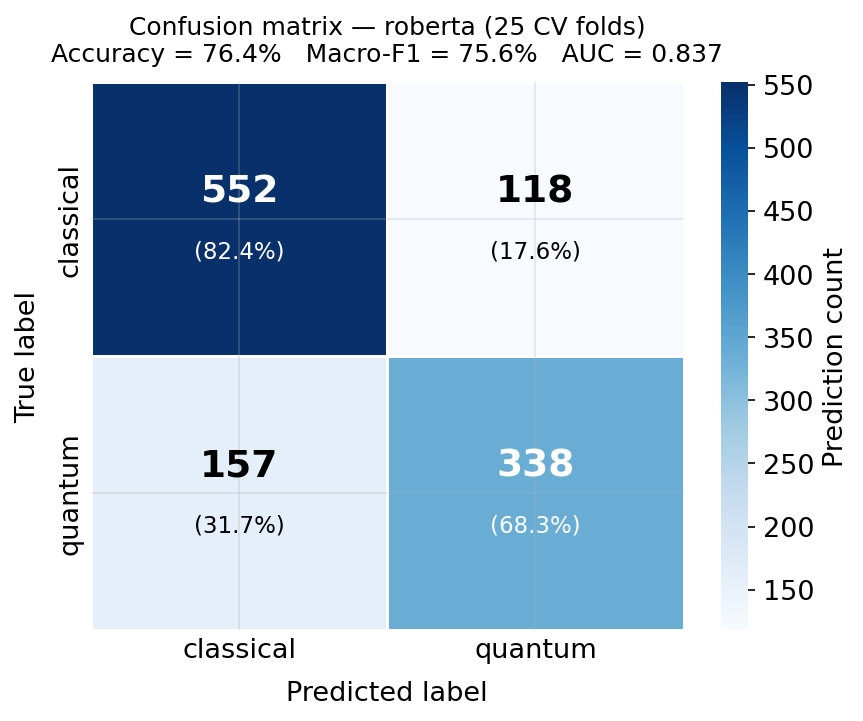

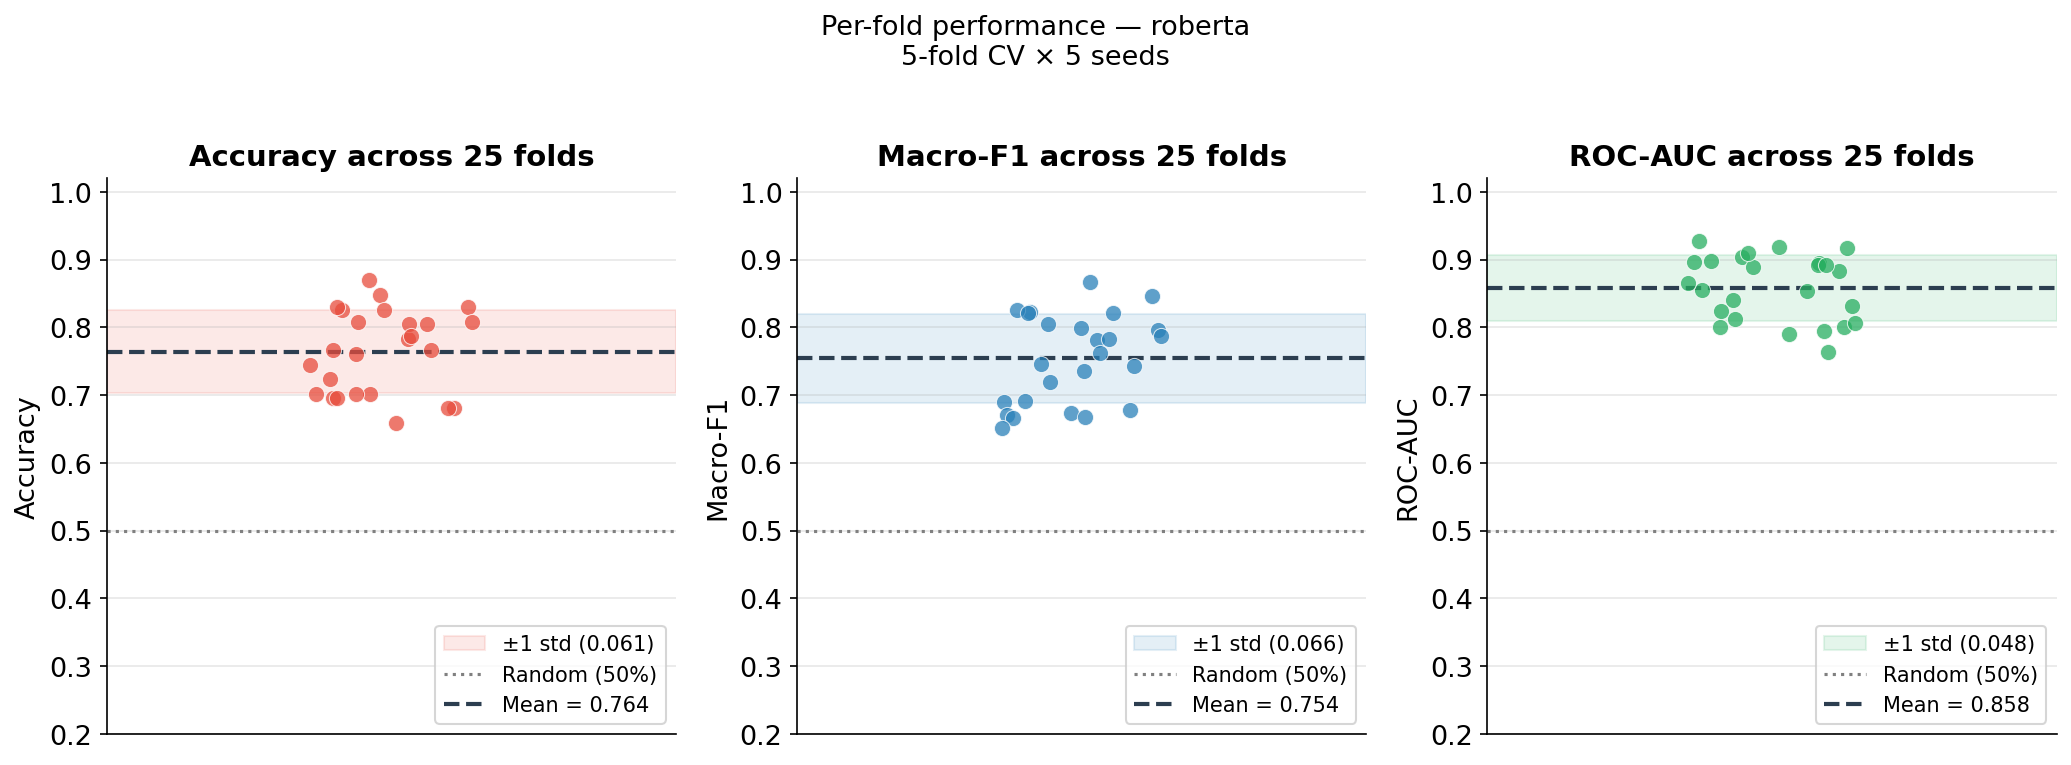

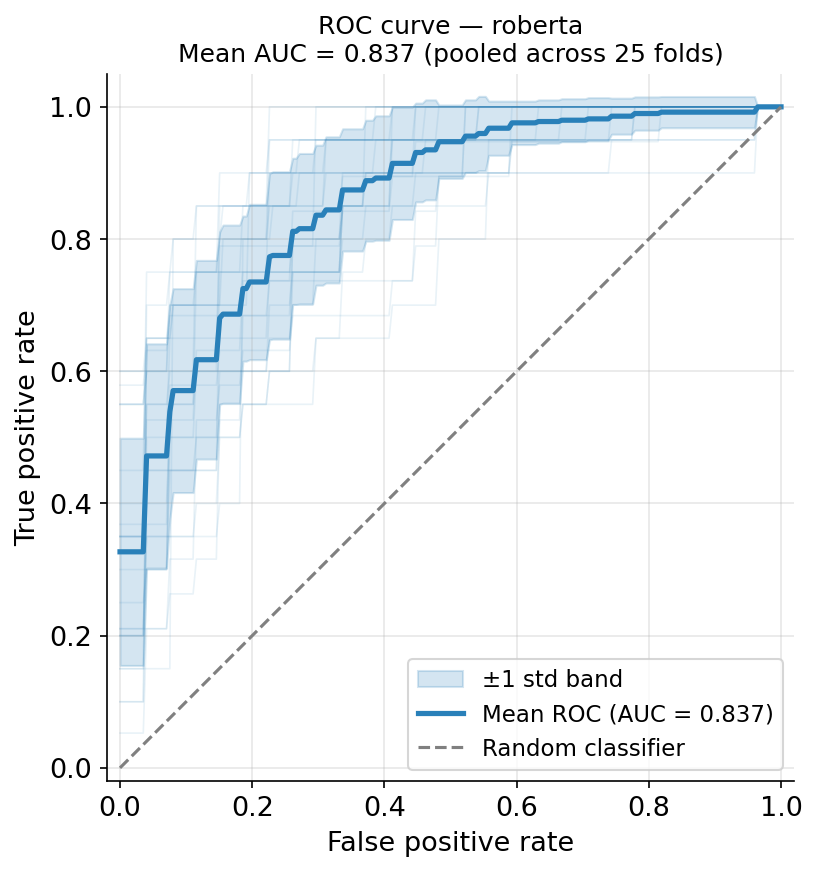


✔ Completed: roberta (acc=0.764, f1=0.754, auc=0.858)

════════════════════════════════════════════════════════════════════════
  EXPERIMENT: CODEBERT
  Model     : microsoft/codebert-base
  Notes     : Code + NL bimodal pretraining (CodeSearchNet)
════════════════════════════════════════════════════════════════════════


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.6980964541435242, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1681, 'eval_samples_per_second': 130.847, 'eval_steps_per_second': 5.948, 'epoch': 1.0}
{'eval_loss': 0.6830748319625854, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1659, 'eval_samples_per_second': 132.599, 'eval_steps_per_second': 6.027, 'epoch': 2.0}
{'eval_loss': 0.6733648777008057, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1676, 'eval_samples_per_second': 131.296, 'eval_steps_per_second': 5.968, 'epoch': 3.0}
{'eval_loss': 0.6447546482086182, 'eval_accuracy': 0.6818181818181818, 'eval_f1_macro': 0.6644880174291938, 'eval_f1_weighted': 0.6644880174291938, 'eval_runtime': 0.1663, 'eval_samples_per_second': 132.265, 'eval_steps_per_second': 6.012, 'epoch': 4.0}
{'eval_loss': 

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6970739364624023, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1502, 'eval_samples_per_second': 146.494, 'eval_steps_per_second': 6.659, 'epoch': 1.0}
{'eval_loss': 0.6917371153831482, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1569, 'eval_samples_per_second': 140.172, 'eval_steps_per_second': 6.371, 'epoch': 2.0}
{'eval_loss': 0.6836774945259094, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1568, 'eval_samples_per_second': 140.297, 'eval_steps_per_second': 6.377, 'epoch': 3.0}
{'eval_loss': 0.6664634943008423, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5448275862068965, 'eval_f1_weighted': 0.5448275862068965, 'eval_runtime': 0.1518, 'eval_samples_per_second': 144.896, 'eval_steps_per_second': 6.586, 'epoch': 4.0}
{'eval_loss': 

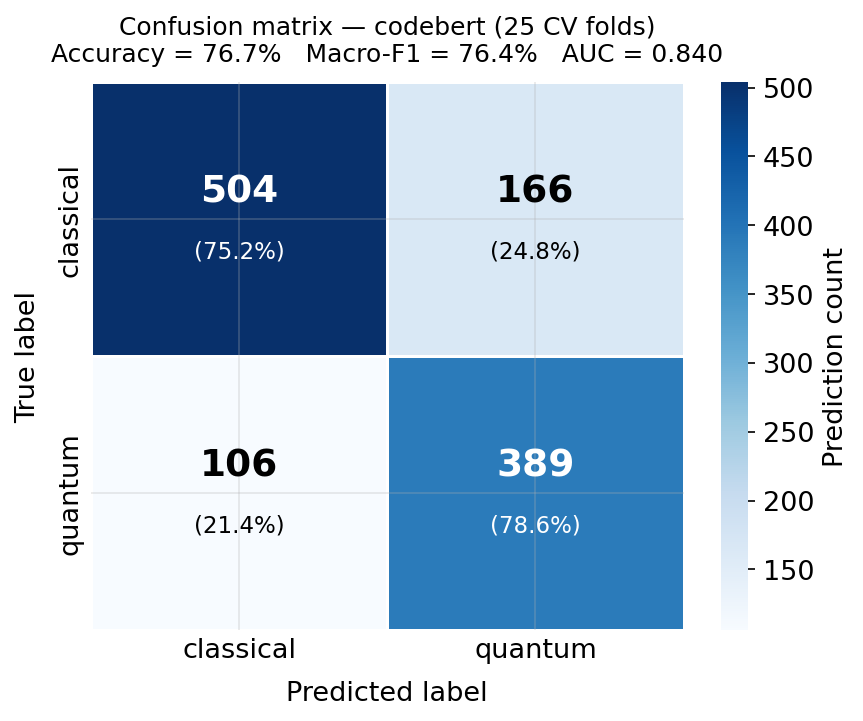

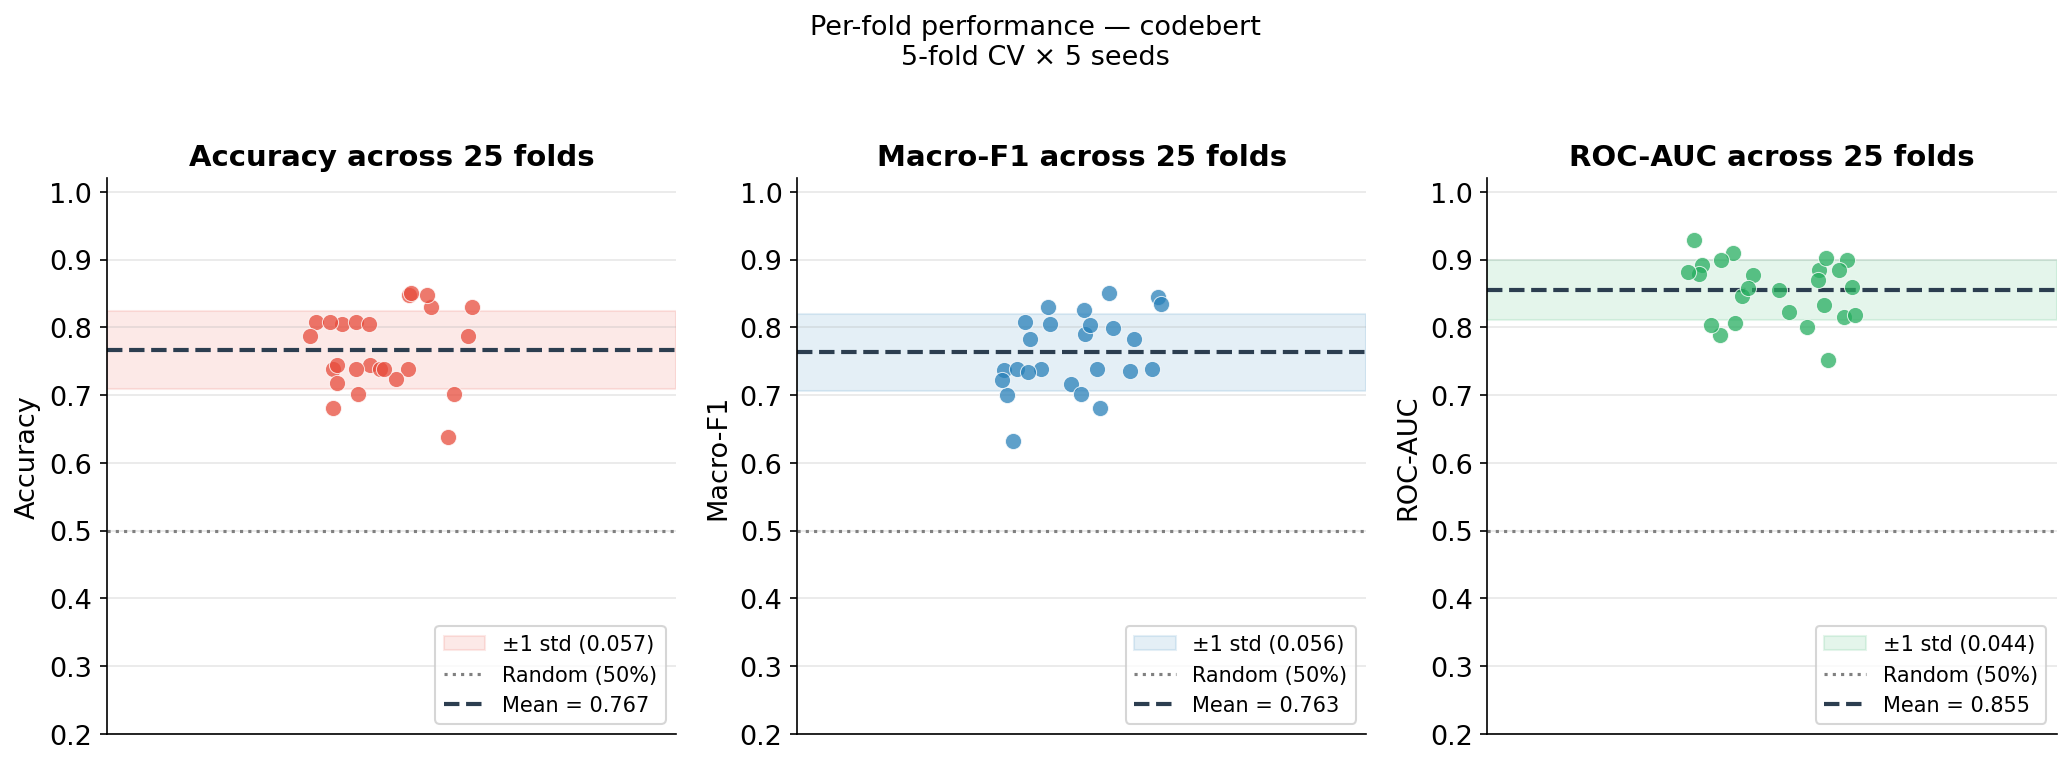

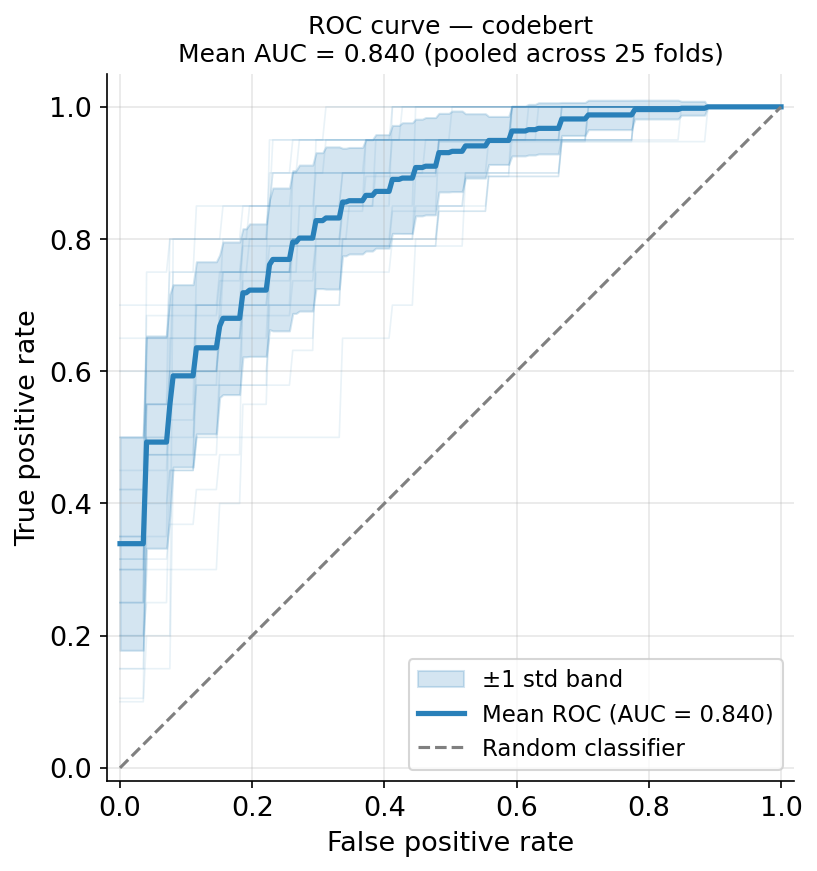


✔ Completed: codebert (acc=0.767, f1=0.763, auc=0.855)

════════════════════════════════════════════════════════════════════════
  EXPERIMENT: GRAPHCODEBERT
  Model     : microsoft/graphcodebert-base
  Notes     : Code + NL + data-flow graph pretraining
════════════════════════════════════════════════════════════════════════


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.67970210313797, 'eval_accuracy': 0.5454545454545454, 'eval_f1_macro': 0.4270833333333333, 'eval_f1_weighted': 0.42708333333333337, 'eval_runtime': 0.1676, 'eval_samples_per_second': 131.28, 'eval_steps_per_second': 5.967, 'epoch': 1.0}
{'eval_loss': 0.6483932733535767, 'eval_accuracy': 0.8636363636363636, 'eval_f1_macro': 0.8633540372670807, 'eval_f1_weighted': 0.8633540372670807, 'eval_runtime': 0.1681, 'eval_samples_per_second': 130.893, 'eval_steps_per_second': 5.95, 'epoch': 2.0}
{'eval_loss': 0.5955482721328735, 'eval_accuracy': 0.8636363636363636, 'eval_f1_macro': 0.8633540372670807, 'eval_f1_weighted': 0.8633540372670807, 'eval_runtime': 0.1697, 'eval_samples_per_second': 129.646, 'eval_steps_per_second': 5.893, 'epoch': 3.0}
{'eval_loss': 0.4984976649284363, 'eval_accuracy': 0.8636363636363636, 'eval_f1_macro': 0.8633540372670807, 'eval_f1_weighted': 0.8633540372670807, 'eval_runtime': 0.1686, 'eval_samples_per_second': 130.473, 'eval_steps_per_second': 5.931, '

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6927430629730225, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5448275862068965, 'eval_f1_weighted': 0.5448275862068965, 'eval_runtime': 0.1523, 'eval_samples_per_second': 144.476, 'eval_steps_per_second': 6.567, 'epoch': 1.0}
{'eval_loss': 0.6842252016067505, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1549, 'eval_samples_per_second': 142.048, 'eval_steps_per_second': 6.457, 'epoch': 2.0}
{'eval_loss': 0.6450275182723999, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5686274509803921, 'eval_f1_weighted': 0.5686274509803921, 'eval_runtime': 0.1563, 'eval_samples_per_second': 140.733, 'eval_steps_per_second': 6.397, 'epoch': 3.0}
{'eval_loss': 0.6028373837471008, 'eval_accuracy': 0.6363636363636364, 'eval_f1_macro': 0.6071428571428572, 'eval_f1_weighted': 0.6071428571428572, 'eval_runtime': 0.1574, 'eval_samples_per_second': 139.778, 'eval_steps_per_second': 6.354

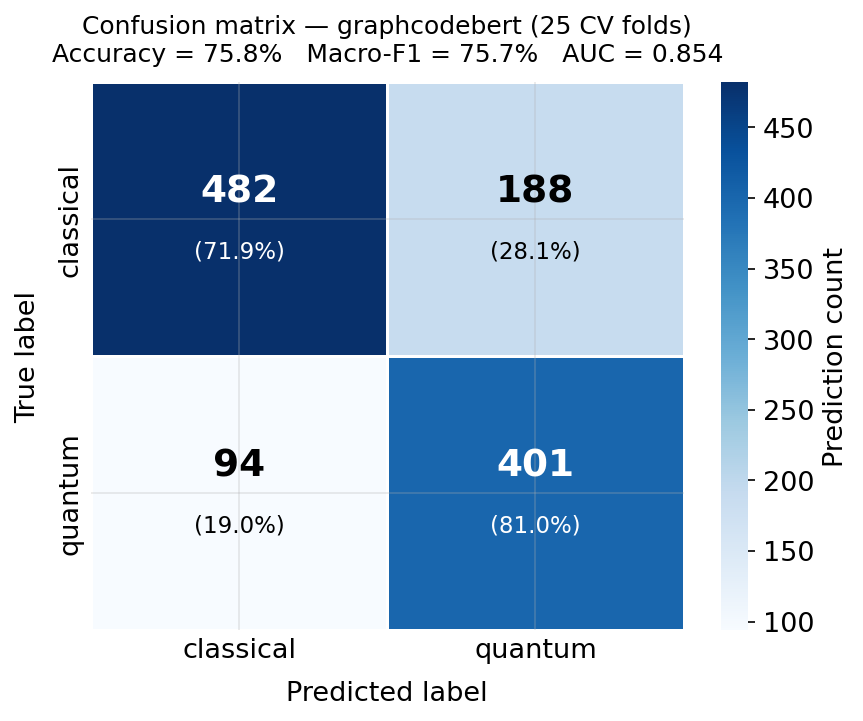

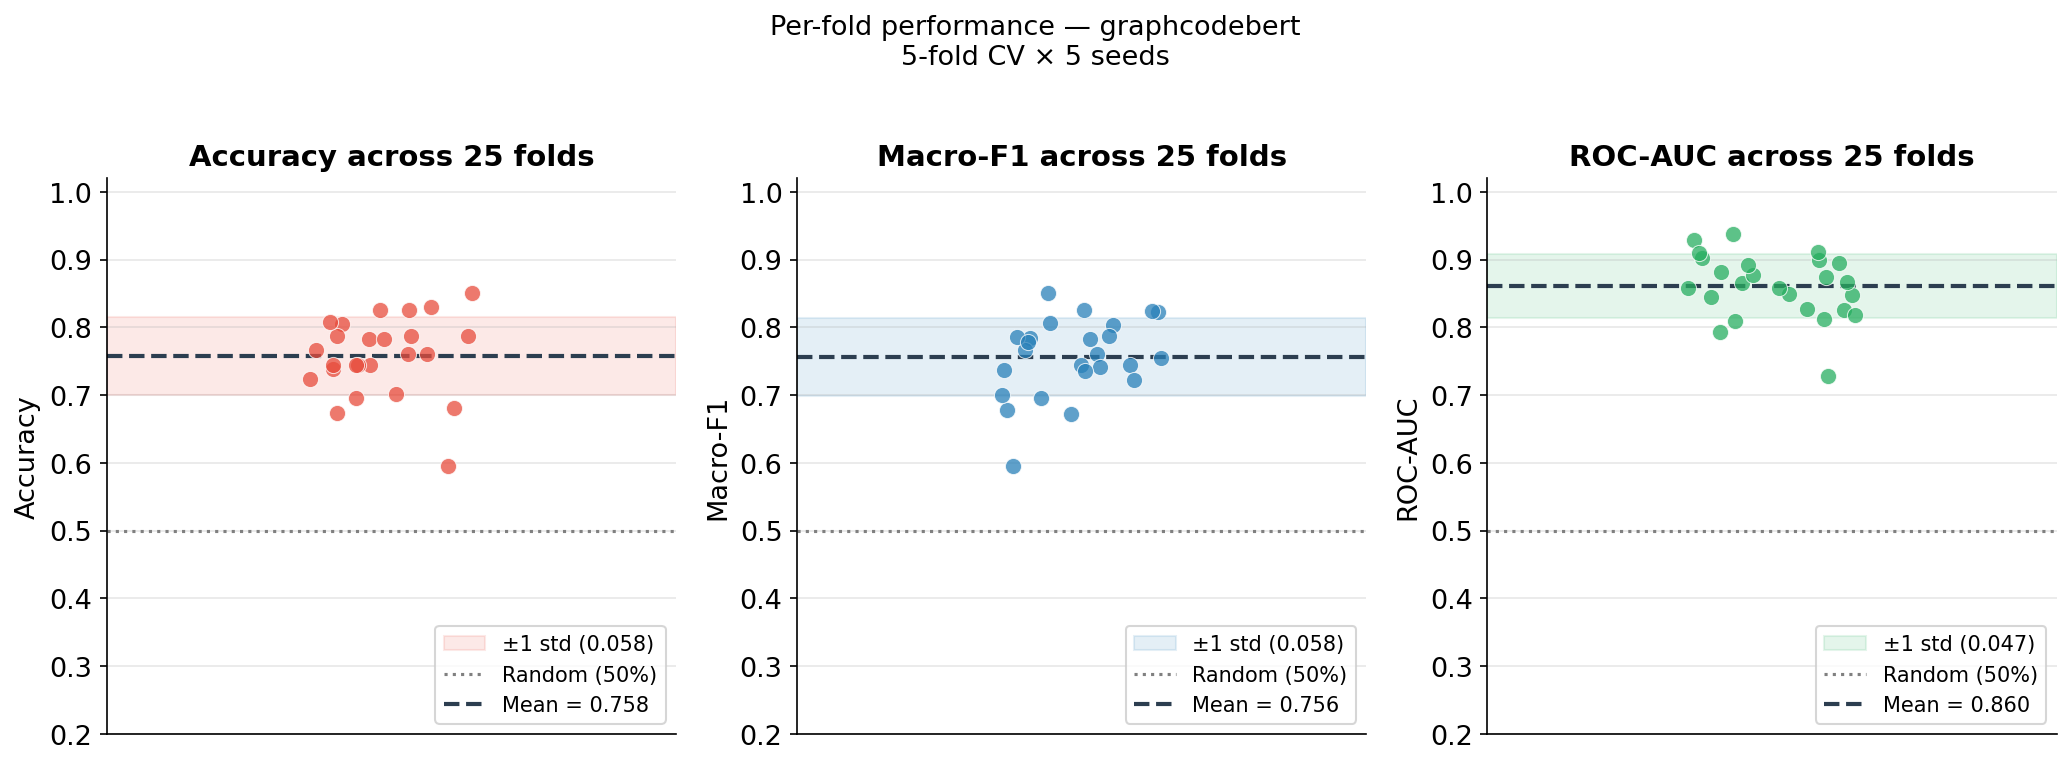

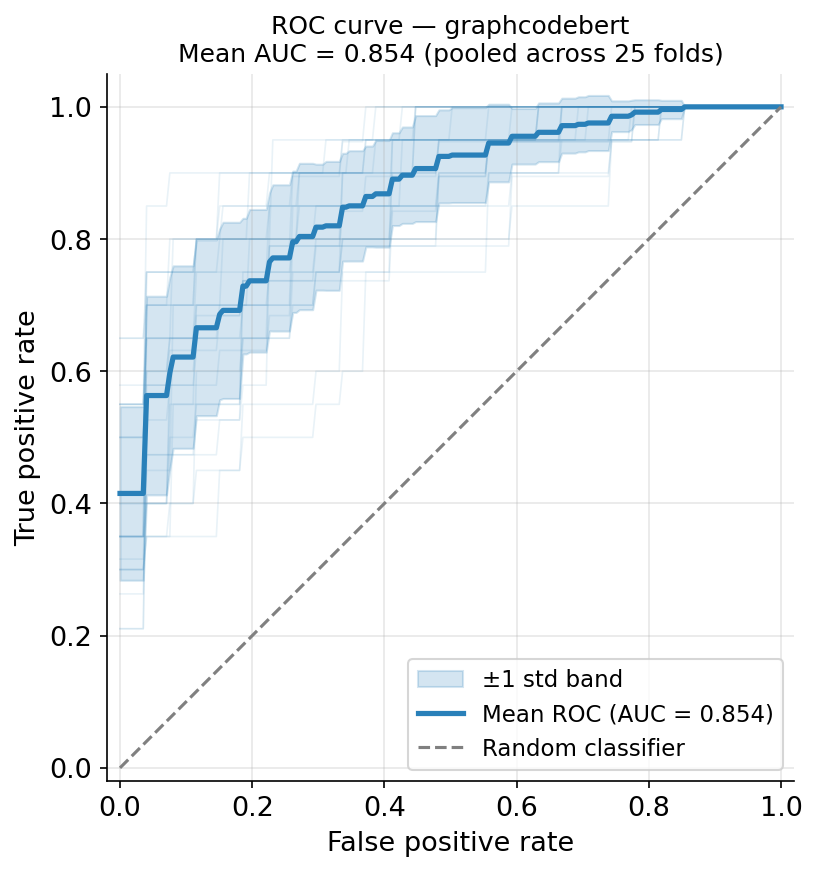


✔ Completed: graphcodebert (acc=0.758, f1=0.756, auc=0.860)

════════════════════════════════════════════════════════════════════════
  ALL THREE EXPERIMENTS COMPLETE
════════════════════════════════════════════════════════════════════════
  roberta         acc=0.764±0.061  f1=0.754±0.066  auc=0.858±0.048
  codebert        acc=0.767±0.057  f1=0.763±0.056  auc=0.855±0.044
  graphcodebert   acc=0.758±0.058  f1=0.756±0.058  auc=0.860±0.047


In [14]:
all_summaries = []

for entry in MODEL_REGISTRY:
    summary = run_full_experiment(
        model_name  = entry['name'],
        model_short = entry['short'],
        description = entry['description'],
    )
    all_summaries.append(summary)
    print(f'\n✔ Completed: {entry["short"]} '
          f'(acc={summary["mean_accuracy"]:.3f}, '
          f'f1={summary["mean_f1_macro"]:.3f}, '
          f'auc={summary["mean_roc_auc"]:.3f})')

print('\n' + '═' * 72)
print('  ALL THREE EXPERIMENTS COMPLETE')
print('═' * 72)
for s in all_summaries:
    print(f'  {s["model_short"]:<14s}  '
          f'acc={s["mean_accuracy"]:.3f}±{s["std_accuracy"]:.3f}  '
          f'f1={s["mean_f1_macro"]:.3f}±{s["std_f1_macro"]:.3f}  '
          f'auc={s["mean_roc_auc"]:.3f}±{s["std_roc_auc"]:.3f}')


## 10. Cross-model comparison table


In [15]:
comparison_df = pd.DataFrame([
    {
        'Model'         : s['model_short'],
        'HF identifier' : s['model_name'],
        'Accuracy'      : f'{s["mean_accuracy"]:.3f} ± {s["std_accuracy"]:.3f}',
        'Macro-F1'      : f'{s["mean_f1_macro"]:.3f} ± {s["std_f1_macro"]:.3f}',
        'ROC-AUC'       : f'{s["mean_roc_auc"]:.3f} ± {s["std_roc_auc"]:.3f}',
        'Pooled Acc'    : f'{s["pooled_accuracy"]:.3f}',
        'Pooled F1'     : f'{s["pooled_f1_macro"]:.3f}',
    }
    for s in all_summaries
])

print('Cross-model comparison (mean ± std across 25 CV folds):\n')
print(comparison_df.to_string(index=False))

comparison_df.to_csv('/kaggle/working/cross_model_comparison.csv', index=False)
print('\nSaved: /kaggle/working/cross_model_comparison.csv')


Cross-model comparison (mean ± std across 25 CV folds):

        Model                HF identifier      Accuracy      Macro-F1       ROC-AUC Pooled Acc Pooled F1
      roberta                 roberta-base 0.764 ± 0.061 0.754 ± 0.066 0.858 ± 0.048      0.764     0.756
     codebert      microsoft/codebert-base 0.767 ± 0.057 0.763 ± 0.056 0.855 ± 0.044      0.767     0.764
graphcodebert microsoft/graphcodebert-base 0.758 ± 0.058 0.756 ± 0.058 0.860 ± 0.047      0.758     0.757

Saved: /kaggle/working/cross_model_comparison.csv


## 11. Cross-model comparison figure

Three-way comparison across accuracy, macro-F1, and ROC-AUC. Error bars are
±1 SD across the 25 folds. Significance brackets show paired Welch's
*t*-tests between adjacent models.


  Accuracy   | roberta        vs codebert      : Δ=-0.002  t=-0.18  p=0.861  n.s.
  Accuracy   | codebert       vs graphcodebert : Δ=+0.009  t=+0.99  p=0.334  n.s.
  Accuracy   | roberta        vs graphcodebert : Δ=+0.006  t=+0.63  p=0.533  n.s.
  Macro-F1   | roberta        vs codebert      : Δ=-0.009  t=-0.63  p=0.533  n.s.
  Macro-F1   | codebert       vs graphcodebert : Δ=+0.007  t=+0.81  p=0.428  n.s.
  Macro-F1   | roberta        vs graphcodebert : Δ=-0.002  t=-0.20  p=0.840  n.s.
  ROC-AUC    | roberta        vs codebert      : Δ=+0.003  t=+0.42  p=0.681  n.s.
  ROC-AUC    | codebert       vs graphcodebert : Δ=-0.006  t=-1.28  p=0.213  n.s.
  ROC-AUC    | roberta        vs graphcodebert : Δ=-0.002  t=-0.28  p=0.782  n.s.


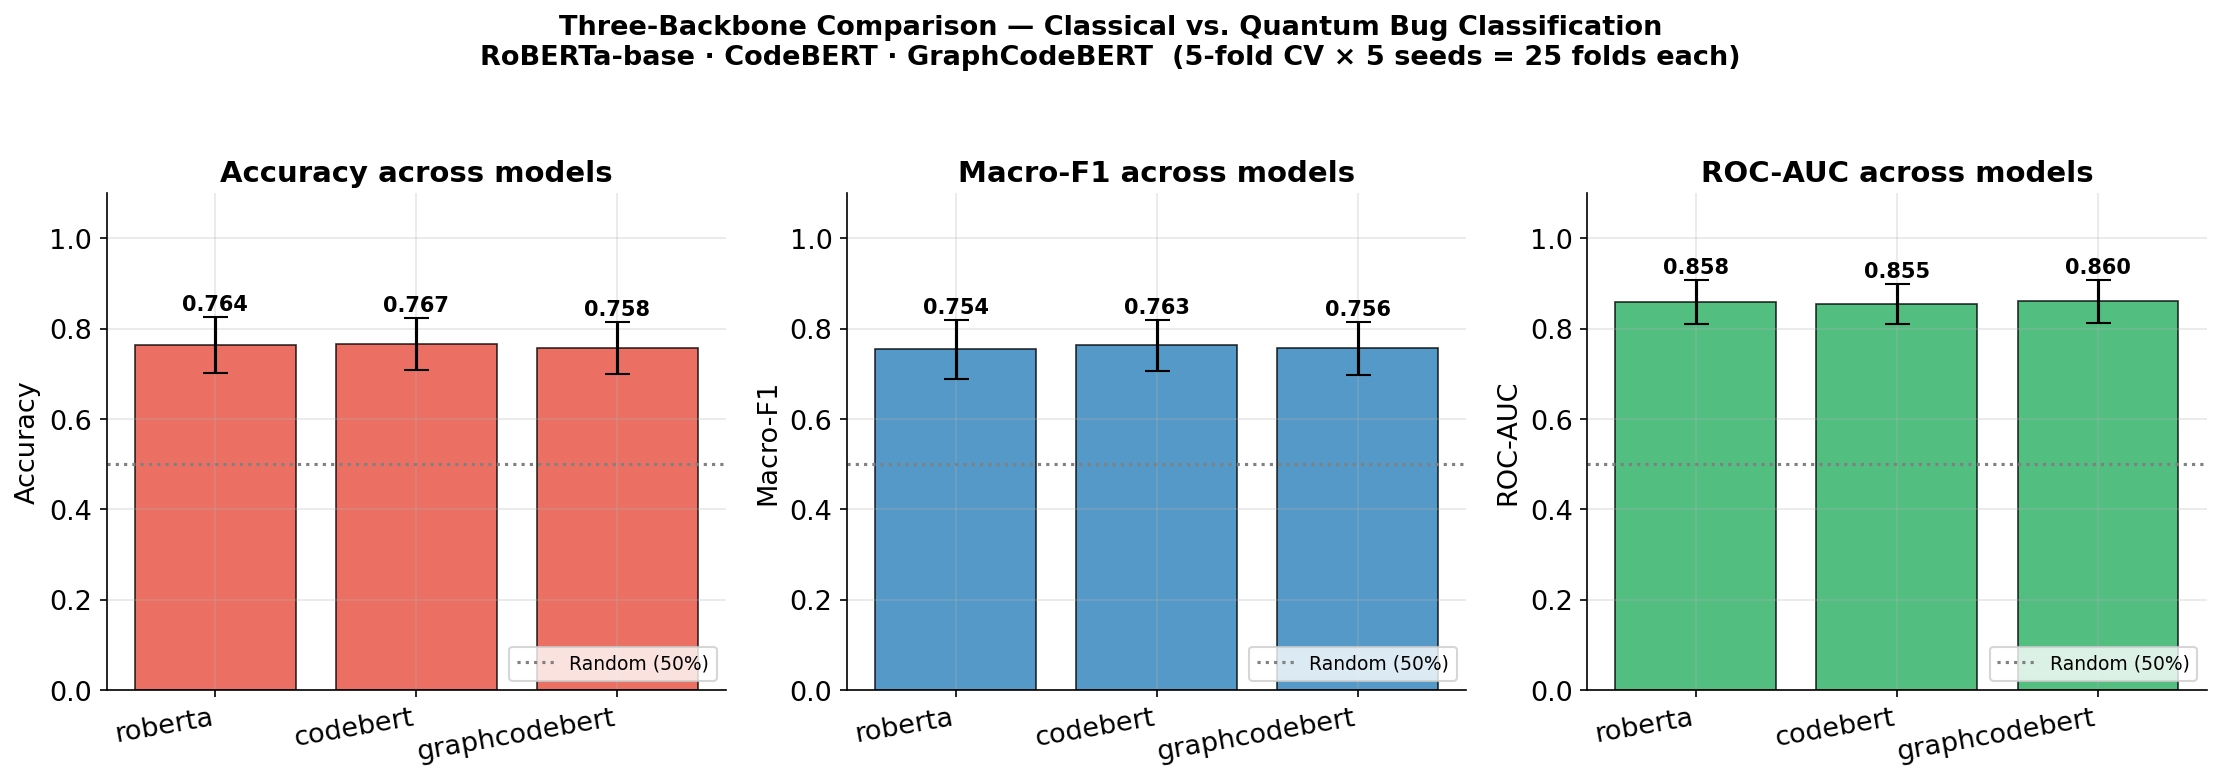

In [16]:
from scipy.stats import ttest_rel

model_shorts = [s['model_short'] for s in all_summaries]
n_models     = len(all_summaries)
metric_keys  = [
    ('mean_accuracy', 'std_accuracy', 'fold_accs',  'Accuracy', '#e74c3c'),
    ('mean_f1_macro', 'std_f1_macro', 'fold_f1s',   'Macro-F1', '#2980b9'),
    ('mean_roc_auc',  'std_roc_auc',  'fold_aucs',  'ROC-AUC',  '#27ae60'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
xpos = np.arange(n_models)

for ax, (mkey, skey, fkey, label, color) in zip(axes, metric_keys):
    means = [s[mkey] for s in all_summaries]
    stds  = [s[skey] for s in all_summaries]
    bars  = ax.bar(xpos, means, yerr=stds, capsize=6,
                   color=color, alpha=0.80, edgecolor='black', linewidth=0.8)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (50%)')
    ax.set_xticks(xpos)
    ax.set_xticklabels(model_shorts, rotation=10, ha='right')
    ax.set_ylim(0, 1.10)
    ax.set_ylabel(label)
    ax.set_title(f'{label} across models', fontweight='bold')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.015,
                f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
    # Pairwise paired t-tests (each fold paired across models since CV seeds match)
    pairs = [(0, 1), (1, 2), (0, 2)]
    for k, (a, b) in enumerate(pairs):
        try:
            t_stat, p_val = ttest_rel(all_summaries[a][fkey], all_summaries[b][fkey])
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
            print(f'  {label:<10s} | {model_shorts[a]:<14s} vs {model_shorts[b]:<14s}: '
                  f'Δ={all_summaries[a][mkey]-all_summaries[b][mkey]:+.3f}  '
                  f't={t_stat:+.2f}  p={p_val:.3f}  {sig}')
        except Exception as e:
            print(f'  t-test failed: {e}')
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle(
    'Three-Backbone Comparison — Classical vs. Quantum Bug Classification\n'
    'RoBERTa-base · CodeBERT · GraphCodeBERT  (5-fold CV × 5 seeds = 25 folds each)',
    fontsize=13, y=1.04, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_cross_model_comparison.png', bbox_inches='tight')
plt.show()


## 12. ROC overlay — all three backbones


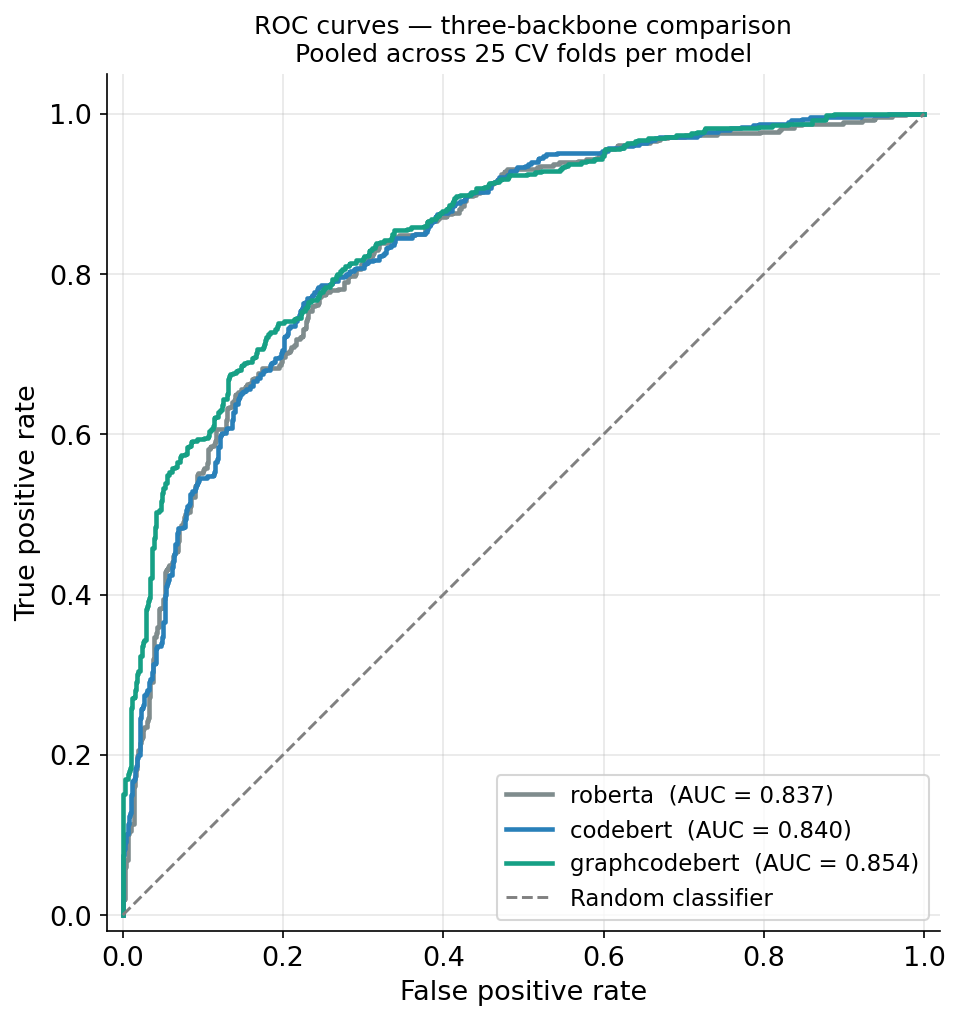

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
base_fpr = np.linspace(0, 1, 200)
overlay_colors = {'roberta': '#7f8c8d', 'codebert': '#2980b9', 'graphcodebert': '#16a085'}

for s in all_summaries:
    y_true_arr = np.array(s['y_true_all'])
    probs_arr  = np.array(s['probs_all'])
    fpr, tpr, _ = roc_curve(y_true_arr, probs_arr[:, 1])
    auc_val = roc_auc_score(y_true_arr, probs_arr[:, 1])
    color = overlay_colors.get(s['model_short'], '#34495e')
    ax.plot(fpr, tpr, linewidth=2.2, color=color,
            label=f'{s["model_short"]}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.4, label='Random classifier')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — three-backbone comparison\n'
             'Pooled across 25 CV folds per model',
             fontsize=12)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_roc_overlay.png', bbox_inches='tight')
plt.show()


## 13. Per-fold accuracy — paired across models

Each line connects the same fold (same train/test split) across the three
models. Crossing lines mean a model that wins on average can still lose on
specific folds — useful for honest reporting on a small dataset.


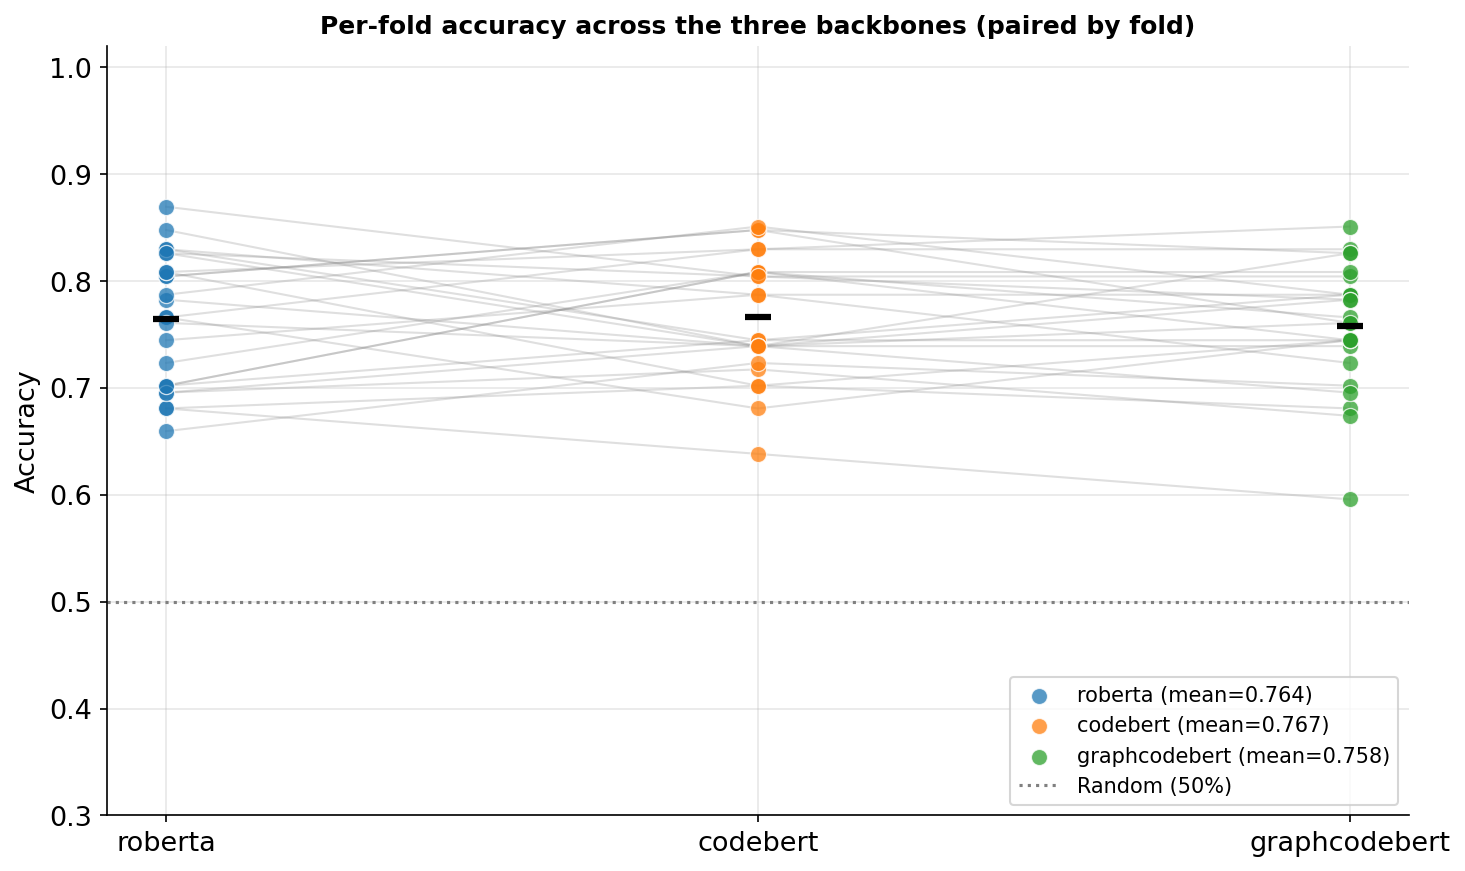

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
n_folds = len(all_summaries[0]['fold_accs'])
xpos    = np.arange(n_models)

# Lines connecting matched folds
for fold_i in range(n_folds):
    yvals = [s['fold_accs'][fold_i] for s in all_summaries]
    ax.plot(xpos, yvals, color='gray', alpha=0.25, linewidth=1.0, zorder=1)

# Dots per model
for k, s in enumerate(all_summaries):
    ax.scatter([k] * n_folds, s['fold_accs'], s=60, alpha=0.75,
               edgecolor='white', linewidth=0.6, zorder=3,
               label=f'{s["model_short"]} (mean={s["mean_accuracy"]:.3f})')
    # Mean marker
    ax.scatter([k], [s['mean_accuracy']], s=160, marker='_',
               color='black', linewidth=3, zorder=4)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (50%)')
ax.set_xticks(xpos)
ax.set_xticklabels(model_shorts)
ax.set_ylim(0.3, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Per-fold accuracy across the three backbones (paired by fold)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_paired_per_fold.png', bbox_inches='tight')
plt.show()


## 14. Save combined results


In [19]:
# Strip the heavy y_true_all / probs_all arrays from the summary file
# (per-model JSON files already have them via results_all)
combined = {
    'task'          : 'classical_vs_quantum_binary',
    'n_samples'     : len(labeled),
    'cv_setup'      : f'{N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {N_FOLDS*len(CV_SEEDS)} folds per model',
    'models'        : []
}
for s in all_summaries:
    combined['models'].append({k: v for k, v in s.items()
                               if k not in ('y_true_all', 'y_pred_all', 'probs_all', 'epoch_logs')})

with open('/kaggle/working/cross_model_results.json', 'w') as f:
    json.dump(combined, f, indent=2, default=str)

print('Saved to /kaggle/working/:')
saved = [
    'cross_model_results.json',
    'cross_model_comparison.csv',
    'fig_cross_model_comparison.png',
    'fig_roc_overlay.png',
    'fig_paired_per_fold.png',
]
for s in all_summaries:
    saved.extend([
        f'results_{s["model_short"]}.json',
        f'per_fold_{s["model_short"]}.csv',
        f'fig1_confusion_matrix_{s["model_short"]}.png',
        f'fig2_fold_distribution_{s["model_short"]}.png',
        f'fig3_roc_curve_{s["model_short"]}.png',
    ])
for fn in saved:
    print(f'  {fn}')


Saved to /kaggle/working/:
  cross_model_results.json
  cross_model_comparison.csv
  fig_cross_model_comparison.png
  fig_roc_overlay.png
  fig_paired_per_fold.png
  results_roberta.json
  per_fold_roberta.csv
  fig1_confusion_matrix_roberta.png
  fig2_fold_distribution_roberta.png
  fig3_roc_curve_roberta.png
  results_codebert.json
  per_fold_codebert.csv
  fig1_confusion_matrix_codebert.png
  fig2_fold_distribution_codebert.png
  fig3_roc_curve_codebert.png
  results_graphcodebert.json
  per_fold_graphcodebert.csv
  fig1_confusion_matrix_graphcodebert.png
  fig2_fold_distribution_graphcodebert.png
  fig3_roc_curve_graphcodebert.png


## 15. Summary

| Item | Value |
|---|---|
| Task | Binary: classical vs. quantum bug classification |
| Models compared | `roberta-base` · `microsoft/codebert-base` · `microsoft/graphcodebert-base` |
| Architecture | All three are 125M-param RoBERTa encoders (capacity controlled) |
| Dataset | 233 labeled samples (134 classical, 99 quantum) |
| CV setup per model | 5-fold × 5 seeds = 25 fold-runs |
| Total fold-runs | 75 |
| Random baseline | 50% balanced / ~58% majority-class |
| Class balance | Weighted CE + minority oversampling |
| Early stopping | `ManualEarlyStoppingCallback` (patience=4, on macro-F1) |
| Disk fix | `save_strategy='no'` + `shutil.rmtree` per fold |
| Statistical test | Paired Welch's *t*-test across the 25 paired folds |

### What this experiment isolates

Because all three models are the same architecture and parameter count
(RoBERTa-base, 125M), any difference in performance on this task comes
**from pretraining data alone**:

- `roberta-base` — control (English text only, no code exposure)
- `microsoft/codebert-base` — adds code + NL bimodal pretraining
- `microsoft/graphcodebert-base` — additionally adds data-flow graph supervision

### Output

Per-model artifacts:
- `fig1_confusion_matrix_<short>.png`
- `fig2_fold_distribution_<short>.png`
- `fig3_roc_curve_<short>.png`
- `results_<short>.json`
- `per_fold_<short>.csv`

Cross-model artifacts:
- `fig_cross_model_comparison.png` — three-metric bar chart with significance
- `fig_roc_overlay.png` — pooled ROC curves overlaid
- `fig_paired_per_fold.png` — paired per-fold accuracy strip plot
- `cross_model_comparison.csv` — summary table
- `cross_model_results.json` — full results
